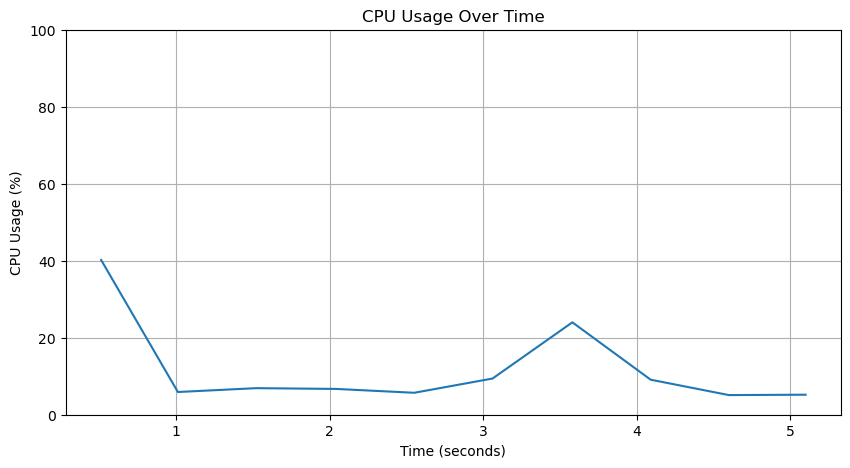

In [9]:
import psutil
import matplotlib.pyplot as plt
import time

# Collect CPU usage samples
duration = 5  # seconds
interval = 0.5  # seconds between samples

timestamps = []
cpu_usage = []

start = time.time()
while time.time() - start < duration:
    cpu_usage.append(psutil.cpu_percent(interval=interval))
    timestamps.append(round(time.time() - start, 2))

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(timestamps, cpu_usage, marker=None, linestyle='-', color='tab:blue')
plt.title('CPU Usage Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('CPU Usage (%)')
plt.ylim(0, 100)
plt.grid(True)
plt.show()

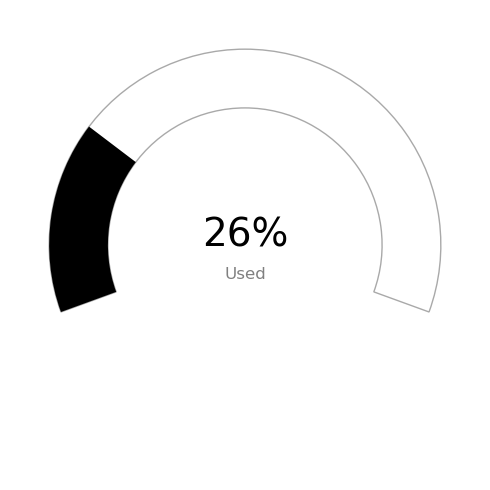

In [40]:
import psutil
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge

# Prime psutil, then read current usage
psutil.cpu_percent()
used = psutil.cpu_percent(interval=1)

# --- Gauge span configuration ---
span = 220          # total sweep of the gauge in degrees (180 = half, 270 = 3/4, etc.)
start_angle = 270 + (360 - span) / 2   # centers the gauge symmetrically
end_angle = start_angle + span

# Fraction of the gauge filled by "used" (fills backward from the end)
fill_angle = end_angle - span * (used / 100)

width = 0.3   # thickness of the ring
r = 1.0

fig, ax = plt.subplots(figsize=(5, 5))

# Background arc (full span, gray)
ax.add_patch(Wedge((0, 0), r, start_angle, end_angle,
                   width=width, facecolor='none', edgecolor='darkgrey', linewidth=1))

# Foreground arc (used portion, blue) — drawn from fill_angle to end_angle
ax.add_patch(Wedge((0, 0), r, fill_angle, end_angle,
                   width=width, facecolor='black'))

# Center text
ax.text(0, 0.05, f'{used:.0f}%', ha='center', va='center', fontsize=28)
ax.text(0, -0.15, 'Used', ha='center', va='center', fontsize=12, color='gray')

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()